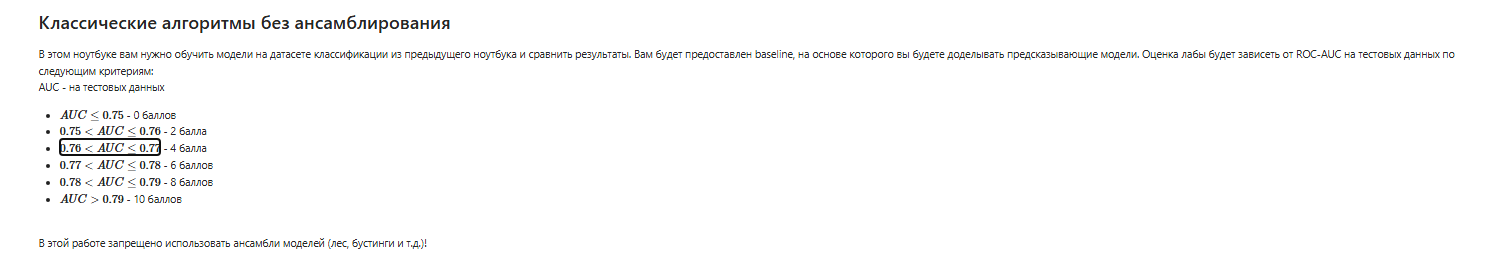

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [ ]:
data = pd.read_csv('german.csv', sep=';')

data.head()

In [ ]:
# target
y = data.iloc[:, -1]

# признаки
X = data.iloc[:, :-1]

# если target = 1/2 → делаем 0/1
y = y.replace({1: 1, 2: 0})

# кодирование категорий
X = pd.get_dummies(X)

X = X.to_numpy()
y = y.to_numpy()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Для решения задачи классификации была использована логистическая регрессия из библиотеки sklearn.
Данные были предварительно обработаны, категориальные признаки закодированы, а также выполнена нормализация.
Модель была обучена на обучающей выборке и протестирована на тестовой.
Качество оценено с помощью метрик accuracy, precision, recall, F1 и ROC-AUC.